### Config

In [1]:
data_root_path = "/media/data/minhht/moe_plantdeasse/data/tomato_only"
checkpoint_path = "/media/data/minhht/moe_plantdeasse/notebook/mobilenetv3_large.pth"
num_classes = 8

### Load Dataset

In [2]:
"""
Utility Functions and Dataset Loading Classes.

This module provides helper functions and dataset classes for loading and processing
plant disease images. It includes the LoadDataset class for structured data loading
with support for train/validation/test splits.

Key Features:
    - Automatic dataset splitting with stratification
    - Class to index mapping for label encoding
    - Image loading with PIL
    - Transform pipeline support via Albumentations
"""

import os
from typing import List, Tuple, Dict, Literal, Optional
from pathlib import Path

import numpy as np
import torch
from torch.utils.data import Dataset
from torchvision.transforms import transforms

from PIL import Image
from sklearn.model_selection import train_test_split


class LoadDataset(Dataset):
    """
    Dataset loader for plant disease classification.
    
    Loads images from a structured directory of disease classes and provides
    automatic train/validation/test splitting with stratification to ensure
    balanced class distribution across splits.
    
    The dataset expects a directory structure like:
        root_dir/
        ├── Tomato_Bacterial_spot/
        ├── Tomato_Early_blight/
        ├── Tomato_healthy/
        └── ... (other disease classes)
    
    Attributes:
        root_dir (Path): Root directory containing disease class folders
        split (str): Dataset split ('train', 'val', or 'test')
        train_ratio (float): Proportion of data for training
        image_paths (List[str]): List of image file paths for the selected split
        labels (List[int]): Class labels corresponding to image_paths
        class_to_idx (Dict[str, int]): Mapping from class name to class index
        idx_to_class (Dict[int, str]): Mapping from class index to class name
    """

    def __init__(
        self,
        root_dir: Path,
        split: Literal['train', 'validation', 'test'],
        train_ratio: float = 0.8,
        transform: transforms.Compose = None
    ) -> None:
        """
        Initialize the dataset loader.
        
        Args:
            root_dir (Path): Root directory containing class subdirectories
            split (str, optional): Dataset split - 'train', 'val', or 'test'. Defaults to 'train'.
            train_ratio (float, optional): Proportion of data for training (0 to 1). Defaults to 0.8.
            transform (transforms.Compose, optional): Image transformation pipeline. Defaults to None.
        """
        self.root_dir = root_dir
        self.transform = transform
        self.split = split
        self.train_ratio = train_ratio
        self.image_paths, self.labels, self.class_to_idx, self.idx_to_class = self._split_dataset()

    def _load_image(self, root_dir: Path) -> Tuple[List[str], List[int], Dict[str, int], Dict[int, str]]:
        """
        Load all images and labels from the root directory.
        
        Scans the root directory for subdirectories starting with "Tomato" (disease classes),
        collects all image files from each class, and creates class-to-index mappings.
        
        Args:
            root_dir (Path): Root directory containing class subdirectories
            
        Returns:
            Tuple containing:
                - image_paths (List[str]): Absolute paths to all image files
                - labels (List[int]): Class labels (0-indexed) corresponding to each image
                - class_to_idx (Dict[str, int]): Mapping from class name to class index
                - idx_to_class (Dict[int, str]): Mapping from class index to class name
        """
        class_names = sorted(
            [d for d in os.listdir(root_dir)
             if os.path.isdir(os.path.join(root_dir, d))
             and d.startswith("Tomato")]
        )
        class_to_idx = {class_name: idx for idx, class_name in enumerate(class_names)}
        idx_to_class = {idx: class_name for class_name, idx in class_to_idx.items()}
        image_paths = []
        labels = []
        for class_name in class_names:
            dir = os.path.join(root_dir, class_name)
            for fname in os.listdir(dir):
                if fname.lower().endswith(('.png', '.jpg', '.jpeg')):
                    image_paths.append(os.path.join(dir, fname))
                    labels.append(class_to_idx[class_name])
        return image_paths, labels, class_to_idx, idx_to_class

    def _split_dataset(self) -> Tuple[List[str], List[int], Dict[str, int], Dict[int, str]]:
        """
        Split dataset into train, validation, and test sets.
        
        Uses stratified sampling to ensure balanced class distribution across all splits:
        - 80% training, 20% temporary (from train_ratio)
        - Temporary split: 50% validation, 50% test
        
        Returns:
            Tuple containing:
                - image_paths (List[str]): Image paths for the selected split
                - labels (List[int]): Labels for the selected split
                - class_to_idx (Dict[str, int]): Class name to index mapping
                - idx_to_class (Dict[int, str]): Index to class name mapping
                
        Raises:
            ValueError: If split is not 'train', 'val', or 'test'
        """
        image_paths, labels, class_to_idx, idx_to_class = self._load_image(self.root_dir)

        train_paths, temp_paths, train_labels, temp_labels = train_test_split(
            image_paths, labels, test_size= 1-self.train_ratio, stratify=labels, random_state=42, shuffle=True
        )

        val_paths, test_paths, val_labels, test_labels = train_test_split(
            temp_paths, temp_labels, test_size=0.5, stratify=temp_labels, random_state=42, shuffle=True
        )

        if self.split == 'train':
            return train_paths, train_labels, class_to_idx, idx_to_class
        elif self.split == 'validation':
            return val_paths, val_labels, class_to_idx, idx_to_class
        elif self.split == 'test':
            return test_paths, test_labels, class_to_idx, idx_to_class
        else:
            raise ValueError("split must be 'train', 'validation', or 'test'")

    def __len__(self) -> int:
        """
        Return the total number of samples in this dataset split.
        
        Returns:
            int: Number of images in the current split
        """
        return len(self.image_paths)
    
    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, int]:
        """
        Get a single sample from the dataset by index.
        
        Loads an image from disk, applies transformations if specified, and returns
        the transformed image tensor and its corresponding class label.
        
        Args:
            idx (int): Index of the sample to retrieve
            
        Returns:
            Tuple containing:
                - image (torch.Tensor): Transformed image tensor
                - label (int): Class label (0-indexed)
        """
        image_path = self.image_paths[idx]
        label = self.labels[idx]
        image = Image.open(image_path).convert('RGB')
        image = np.array(image)
        if self.transform:
            augumented = self.transform(image=image)
            image = augumented["image"]
        return image, label


In [3]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

transform_pipeline = A.Compose([
    A.Resize(224, 224),
    A.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
    ToTensorV2()
])

train_dataset = LoadDataset(data_root_path, split='train', train_ratio=0.8, transform=transform_pipeline)
val_dataset = LoadDataset(data_root_path, split='validation', train_ratio=0.8, transform=transform_pipeline)
test_dataset = LoadDataset(data_root_path, split='test', train_ratio=0.8, transform=transform_pipeline)

print("Number of training samples:", len(train_dataset))
print("Number of validation samples:", len(val_dataset))
print("Number of test samples:", len(test_dataset))
print("Class to index mapping:", train_dataset.class_to_idx)

/media/data/minhht/moe_plantdeasse/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Number of training samples: 2274
Number of validation samples: 284
Number of test samples: 285
Class to index mapping: {'Tomato Early blight leaf': 0, 'Tomato Septoria leaf spot': 1, 'Tomato leaf': 2, 'Tomato leaf bacterial spot': 3, 'Tomato leaf late blight': 4, 'Tomato leaf mosaic virus': 5, 'Tomato leaf yellow virus': 6, 'Tomato mold leaf': 7}


In [4]:
from torch.utils.data import DataLoader


train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

### Backbone Feature Extractor

In [5]:
import torch
import torch.nn as nn
from torchvision import models

model = models.mobilenet_v3_large(pretrained=True)

# thay classifier
in_features = model.classifier[3].in_features
model.classifier[3] = nn.Linear(in_features, 8)

model.load_state_dict(torch.load(checkpoint_path, map_location="cuda"))
model.classifier = nn.Identity()
model.eval()

/media/data/minhht/moe_plantdeasse/venv/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/media/data/minhht/moe_plantdeasse/venv/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V3_Large_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V3_Large_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/media/data/minhht/moe_plantdeasse/venv/lib/python3.11/site-packages/torch/cuda/__init__.py:283: UserWarning: 
    Found GPU0 NVIDIA GB10 which is of cuda capability 12.1.
    Minimum and Maximum cuda capability supported by this version of PyTorch is
    (8.0) - (12.0)
    
  warnings.warn(


MobileNetV3(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        )
      )
    )
    (2): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 64, kernel_size=(1, 1), stride=(1, 1), bi

In [6]:
dummy_input = torch.randn(1, 3, 224, 224)
with torch.no_grad():
    features = model(dummy_input)
print("Extracted features shape:", features.shape)

Extracted features shape: torch.Size([1, 960])


In [7]:
train_features = []
train_labels = []

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
with torch.no_grad():
    for images, labels in train_loader:
        images = images.to(device)
        features = model(images)
        train_features.append(features.cpu())
        train_labels.append(labels.cpu())

train_features_all = torch.cat(train_features)
train_labels_all = torch.cat(train_labels)
print("Train features shape:", train_features_all.shape)
print("Train labels shape:", train_labels_all.shape)

Train features shape: torch.Size([2274, 960])
Train labels shape: torch.Size([2274])


### Normalize features

In [8]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
train_features_normalized = sc.fit_transform(train_features_all)
print("Normalized train features shape:", train_features_normalized.shape)

Normalized train features shape: (2274, 960)


### Reduce dimentions with t-SNE

In [9]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42)
features_tsne = tsne.fit_transform(train_features_normalized)
print("Dimention after reduction: ", features_tsne.shape)

Dimention after reduction:  (2274, 2)


### Kmeans Clustering

In [10]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

kmeans = KMeans(n_clusters=3, random_state=42)
clusters_labels_kmeans = kmeans.fit_predict(features_tsne)
score = silhouette_score(features_tsne, clusters_labels_kmeans)
print("Silhouette_kmeans:", score)

Silhouette_kmeans: 0.4019545614719391


In [11]:
import joblib

# lưu model
joblib.dump(kmeans, "kmeans_tsne_3clusters.pkl")

['kmeans_tsne_3clusters.pkl']

### Post Process Clustering

[[ 26.578566  -6.538033]
 [-23.330332 -13.542392]
 [  6.684578  27.1974  ]]


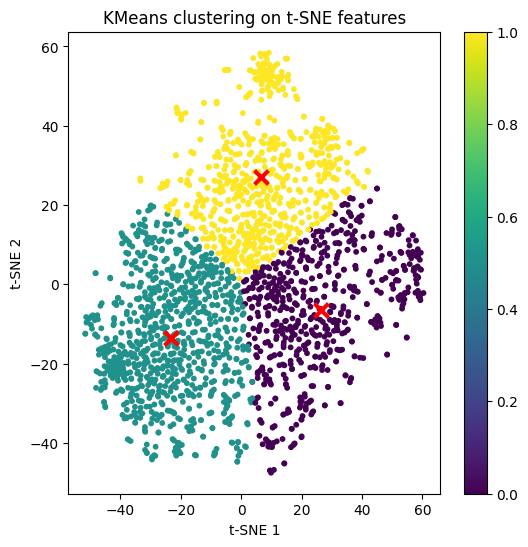

In [12]:
import matplotlib.pyplot as plt


centroids = kmeans.cluster_centers_
print(centroids)
    
plt.figure(figsize=(6,6))
plt.scatter(features_tsne[:,0], features_tsne[:,1], 
            c=clusters_labels_kmeans, cmap='viridis', s=10)
plt.scatter(centroids[:,0], centroids[:,1], c='red', marker='x', s=100, linewidths=3)

plt.title("KMeans clustering on t-SNE features")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.colorbar()
plt.show()

In [13]:
import numpy as np

unique, counts = np.unique(clusters_labels_kmeans, return_counts=True)

for u, c in zip(unique, counts):
    print(f"Cluster {u}: {c} samples")

Cluster 0: 652 samples
Cluster 1: 919 samples
Cluster 2: 703 samples


In [14]:
print("Shape of cluster kmeans is: ", clusters_labels_kmeans.shape)

Shape of cluster kmeans is:  (2274,)


In [15]:
import pandas as pd

df = pd.DataFrame({
    "cluster": clusters_labels_kmeans,
    "label": train_labels_all.numpy()
})

print(pd.crosstab(df["cluster"], df["label"]))

label      0    1    2    3    4    5    6    7
cluster                                        
0        107  259   64  100   53   17   13   39
1         14   38   44   39    5  149  553   77
2         44   40  210   71  118   43   67  110


In [16]:
import numpy as np

clusters = {}

for i in range(3):
    idx = np.where(clusters_labels_kmeans == i)[0]

    clusters[i] = {
        "features": train_features_all[idx],
        "labels": train_labels_all[idx]
    }

    print(f"Cluster {i}: {len(idx)} samples")

Cluster 0: 652 samples
Cluster 1: 919 samples
Cluster 2: 703 samples


### Trainning Experts

In [17]:
import torch
from torch.utils.data import Dataset

class FeatureDataset(Dataset):

    def __init__(self, features, labels):
        super().__init__()
        self.features = torch.tensor(features, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

In [18]:
from torch.utils.data import DataLoader

cluster_loaders = []

for i in range(3):

    dataset = FeatureDataset(
        clusters[i]["features"],
        clusters[i]["labels"]
    )

    loader = DataLoader(
        dataset,
        batch_size=32,
        shuffle=True
    )

    cluster_loaders.append(loader)

/tmp/ipykernel_2422760/548205739.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.features = torch.tensor(features, dtype=torch.float32)
/tmp/ipykernel_2422760/548205739.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.labels = torch.tensor(labels, dtype=torch.long)


In [19]:
import torch.nn as nn

class Expert(nn.Module):

    def __init__(self, input_dim, num_classes):

        super().__init__()

        self.expert = nn.Sequential(

            nn.Linear(input_dim, 512),
            nn.ReLU(),

            nn.Linear(512, 256),
            nn.ReLU(),

            nn.Linear(256, num_classes)

        )

    def forward(self, x):
        return self.expert(x)

In [20]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

input_dim = train_features_all.shape[1]
num_classes = len(torch.unique(train_labels_all))
print("Num classes of Expert are: ", num_classes)

experts = []

for i in range(3):

    model = Expert(input_dim, num_classes).to(device)
    experts.append(model)

Num classes of Expert are:  8


In [21]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

criterion = nn.CrossEntropyLoss()

for i in range(3):

    print(f"\nTraining Expert {i}")

    # dataset của cluster i
    dataset = FeatureDataset(
        clusters[i]["features"],
        clusters[i]["labels"]
    )

    loader = DataLoader(dataset, batch_size=32, shuffle=True)

    # model riêng
    model = Expert(input_dim, num_classes).to(device)

    # optimizer riêng
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    for epoch in range(10):

        total_loss = 0

        for x, y in loader:

            x = x.to(device)
            y = y.to(device)

            optimizer.zero_grad()

            outputs = model(x)
            loss = criterion(outputs, y)

            loss.backward()

            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1} Loss: {total_loss/len(loader):.4f}")

    # lưu expert
    torch.save(model.state_dict(), f"expert_{i}.pth")

    # giải phóng GPU
    del model
    torch.cuda.empty_cache()


Training Expert 0
Epoch 1 Loss: 1.5779
Epoch 2 Loss: 1.0633


/tmp/ipykernel_2422760/548205739.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.features = torch.tensor(features, dtype=torch.float32)
/tmp/ipykernel_2422760/548205739.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.labels = torch.tensor(labels, dtype=torch.long)


Epoch 3 Loss: 0.8116
Epoch 4 Loss: 0.5946


Epoch 5 Loss: 0.4601
Epoch 6 Loss: 0.2980
Epoch 7 Loss: 0.1802
Epoch 8 Loss: 0.1326
Epoch 9 Loss: 0.0941
Epoch 10 Loss: 0.0549

Training Expert 1
Epoch 1 Loss: 1.2835
Epoch 2 Loss: 0.9166
Epoch 3 Loss: 0.7053
Epoch 4 Loss: 0.5431
Epoch 5 Loss: 0.3885
Epoch 6 Loss: 0.2831
Epoch 7 Loss: 0.1935
Epoch 8 Loss: 0.1338
Epoch 9 Loss: 0.0891
Epoch 10 Loss: 0.0603

Training Expert 2
Epoch 1 Loss: 1.6877
Epoch 2 Loss: 1.2602
Epoch 3 Loss: 0.8892
Epoch 4 Loss: 0.6287
Epoch 5 Loss: 0.4585
Epoch 6 Loss: 0.3085
Epoch 7 Loss: 0.2020
Epoch 8 Loss: 0.1065
Epoch 9 Loss: 0.0743
Epoch 10 Loss: 0.0617


### Validation

In [22]:
import joblib

from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
from torchvision import models

import warnings
warnings.filterwarnings("ignore")


# __________________Load Backbone______________________________________
model = models.mobilenet_v3_large(pretrained=True)
in_features = model.classifier[3].in_features
model.classifier[3] = nn.Linear(in_features, 8)

model.load_state_dict(torch.load(checkpoint_path, map_location="cuda"))
model.classifier = nn.Identity()
model.eval()

# __________________Load Kmeans_________________________________________
kmeans = joblib.load("kmeans_tsne_3clusters.pkl")

# __________________Features Extration__________________________________
val_features = []
val_labels = []
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Availabel device is: ', device)
model.to(device)
with torch.no_grad():
    for images, labels in val_loader:

        images = images.to(device)

        features = model(images)

        val_features.append(features.cpu())
        val_labels.append(labels.cpu())   # sửa ở đây

val_features_all = torch.cat(val_features)
val_labels_all = torch.cat(val_labels)
print("Val features shape:", val_features_all.shape)
print("Val labels shape:", val_labels_all.shape)

# _____________________Normalize features______________________________
sc = StandardScaler()
val_features_normalized = sc.fit_transform(val_features_all)
# _____________________t-SNE reduce dimentions__________________________
tsne = TSNE(n_components=2, random_state=42)
features_tsne = tsne.fit_transform(val_features_normalized)

# ____________________Routing___________________________________________
val_clusters = kmeans.predict(features_tsne)
print(val_clusters)
experts = []

for i in range(3):

    expert = Expert(input_dim, num_classes)
    expert.load_state_dict(torch.load(f"expert_{i}.pth"))
    expert.to(device)
    expert.eval()

    experts.append(expert)

# _________________________Predict______________________________________
y_pred = []

for i in range(len(val_features_all)):

    feature = torch.tensor(val_features_all[i]).float().unsqueeze(0).to(device)

    cluster_id = val_clusters[i]

    expert = experts[cluster_id]

    output = expert(feature)

    pred = torch.argmax(output, dim=1).item()

    y_pred.append(pred)

Availabel device is:  cuda
Val features shape: torch.Size([284, 960])
Val labels shape: torch.Size([284])
[1 1 0 0 2 1 1 1 2 1 1 0 2 1 1 1 2 2 2 1 1 0 1 2 1 2 1 1 2 1 1 0 1 1 0 2 2
 0 2 0 1 1 1 0 1 0 1 2 0 1 2 1 0 2 1 1 0 0 0 0 0 0 1 0 0 2 2 0 1 1 0 0 0 1
 0 1 0 1 2 1 1 2 0 2 1 0 0 2 2 1 0 1 0 1 0 1 1 0 1 2 1 1 0 0 1 2 1 2 1 0 1
 1 1 0 2 0 0 0 1 1 1 0 1 2 0 2 1 2 2 2 0 2 1 1 0 0 1 0 2 1 0 1 0 1 2 0 0 0
 1 2 2 0 2 1 1 1 1 0 2 2 1 0 0 2 0 1 0 2 2 1 1 1 2 0 0 2 1 1 0 1 2 0 0 2 1
 1 2 1 0 1 0 1 1 1 1 0 2 1 1 0 0 2 1 0 1 0 1 0 2 1 1 1 1 0 0 0 0 1 1 0 1 0
 2 0 1 0 1 2 0 1 1 1 0 1 1 0 0 1 1 0 0 1 1 2 1 0 1 1 2 1 0 0 0 1 2 0 0 0 1
 0 2 1 1 1 0 0 2 1 0 1 0 2 1 0 1 1 0 0 0 0 0 1 1 0]


In [23]:
from sklearn.metrics import classification_report

print(classification_report(val_labels_all.numpy(), y_pred))

              precision    recall  f1-score   support

           0       0.43      0.14      0.21        21
           1       0.60      0.57      0.59        42
           2       0.43      0.30      0.35        40
           3       0.26      0.58      0.36        26
           4       0.53      0.36      0.43        22
           5       0.39      0.62      0.48        26
           6       0.90      0.72      0.80        79
           7       0.38      0.43      0.40        28

    accuracy                           0.52       284
   macro avg       0.49      0.47      0.45       284
weighted avg       0.57      0.52      0.52       284

